**<h1>IR ALEM 1 - CARDIO_IA FASE 7<h1>**

<h2>IMPORTAÇÃO E INSTALAÇÃO DAS DEPENDÊNCIAS

In [1]:
!apt-get install -y graphviz libgraphviz-dev > /dev/null 2>&1
!pip install pm4py matplotlib pandas numpy pygraphviz > /dev/null 2>&1

import datetime
import random
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pm4py
from pm4py.algo.conformance.tokenreplay import algorithm as token_replay
from pm4py.algo.discovery.inductive import algorithm as inductive_miner
from pm4py.objects.conversion.process_tree import converter as pt_converter
from pm4py.visualization.dfg import visualizer as dfg_visualizer
from pm4py.visualization.petri_net import visualizer as pn_visualizer
from IPython.display import Image, display

%matplotlib inline


<h2>SIMULAÇÃO ESTOCÁSTICA DE PRONTO SOCORRO (COM 4 VARIANTES):<h2>
<p><h3>Variante 1: Linha de Diretriz Padrão-ouro</h3><p>
<p><h3>Variante 2: Gargalo por Superlotação/ Infraestrutura</h3><p>
<p><h3>Variante 3: Erro de omissão - ausência de ECG</h3><p>
<p><h3>Variante 4: Inversão de Diretriz (paciente crítico porta aberta)</h3><p>

In [2]:
def gerar_event_log_iam(num_casos=10000):
    print(f"🏥 MÓDULO 1: Gerando base de dados histórica do Pronto-Socorro com {num_casos} casos...")

    activities = [
        "Admissão Pronto Socorro",
        "Triagem de Risco",
        "Realização de ECG",
        "Interpretação Médica do ECG",
        "Administração de Protocolo de IAM",
        "Encaminhamento para Cateterismo",
        "Alta/Transferência UTI",
        "Aguardando Aparelho ECG"
    ]

    data = []
    base_date = datetime.datetime(2026, 5, 1, 8, 0, 0)

    limite_v1 = int(num_casos * 0.60)  # 60% -> Rota 1
    limite_v2 = int(num_casos * 0.68)  #  8% -> Rota 2
    limite_v3 = int(num_casos * 0.88)  # 20% -> Rota 3

    for case_id in range(1, num_casos + 1):
        current_time = base_date + datetime.timedelta(minutes=15 * case_id)

        if case_id <= limite_v1:
            v_type = 1
        elif case_id <= limite_v2:
            v_type = 4
        elif case_id <= limite_v3:
            v_type = 2
        else:
            v_type = 3

        # --- VARIANTE 1: Caminho Feliz ---
        if v_type == 1:
            data.append([f"CASE_{case_id}", activities[0], current_time + datetime.timedelta(minutes=0)])
            data.append([f"CASE_{case_id}", activities[1], current_time + datetime.timedelta(minutes=5)])
            data.append([f"CASE_{case_id}", activities[2], current_time + datetime.timedelta(minutes=10)])
            data.append([f"CASE_{case_id}", activities[3], current_time + datetime.timedelta(minutes=20)])
            data.append([f"CASE_{case_id}", activities[4], current_time + datetime.timedelta(minutes=30)])
            data.append([f"CASE_{case_id}", activities[5], current_time + datetime.timedelta(minutes=50)])
            data.append([f"CASE_{case_id}", activities[6], current_time + datetime.timedelta(hours=3)])

        # --- VARIANTE 2: Gargalo por Superlotação ---
        elif v_type == 2:
            data.append([f"CASE_{case_id}", activities[0], current_time + datetime.timedelta(minutes=0)])
            data.append([f"CASE_{case_id}", activities[1], current_time + datetime.timedelta(minutes=45)])
            data.append([f"CASE_{case_id}", activities[7], current_time + datetime.timedelta(minutes=50)])
            data.append([f"CASE_{case_id}", activities[2], current_time + datetime.timedelta(minutes=85)])
            data.append([f"CASE_{case_id}", activities[3], current_time + datetime.timedelta(minutes=100)])
            data.append([f"CASE_{case_id}", activities[4], current_time + datetime.timedelta(minutes=110)])
            data.append([f"CASE_{case_id}", activities[5], current_time + datetime.timedelta(minutes=140)])
            data.append([f"CASE_{case_id}", activities[6], current_time + datetime.timedelta(hours=4)])

        # --- VARIANTE 3: Erro de Omissão - Sem ECG ---
        elif v_type == 3:
            data.append([f"CASE_{case_id}", activities[0], current_time + datetime.timedelta(minutes=0)])
            data.append([f"CASE_{case_id}", activities[1], current_time + datetime.timedelta(minutes=5)])
            data.append([f"CASE_{case_id}", activities[4], current_time + datetime.timedelta(minutes=20)])
            data.append([f"CASE_{case_id}", activities[5], current_time + datetime.timedelta(minutes=50)])
            data.append([f"CASE_{case_id}", activities[6], current_time + datetime.timedelta(hours=3)])

        # --- VARIANTE 4: Inversão Justificada ---
        elif v_type == 4:
            data.append([f"CASE_{case_id}", activities[0], current_time + datetime.timedelta(minutes=0)])
            data.append([f"CASE_{case_id}", activities[2], current_time + datetime.timedelta(minutes=5)])
            data.append([f"CASE_{case_id}", activities[1], current_time + datetime.timedelta(minutes=15)])
            data.append([f"CASE_{case_id}", activities[3], current_time + datetime.timedelta(minutes=25)])
            data.append([f"CASE_{case_id}", activities[4], current_time + datetime.timedelta(minutes=35)])
            data.append([f"CASE_{case_id}", activities[5], current_time + datetime.timedelta(minutes=55)])
            data.append([f"CASE_{case_id}", activities[6], current_time + datetime.timedelta(hours=3)])

    df_criado = pd.DataFrame(data, columns=["case_id", "activity", "timestamp"])
    df_criado = df_criado.sort_values(by=["case_id", "timestamp"]).reset_index(drop=True)

    log_formatado = pm4py.format_dataframe(
        df_criado, case_id="case_id", activity_key="activity", timestamp_key="timestamp"
    )
    print("✔️ Log de Eventos integrado com distribuição percentual correta.\n")
    return df_criado, log_formatado


<h2>AUDITORIA DE JANELA CRITICA<h2>

In [3]:
def auditoria_tempo_porta_ecg(df_bruto):
    print("\n⏱️ MÓDULO EXTRA: Calculando métrica regulatória SBC (Tempo Porta-ECG)...")

    admissao = df_bruto[df_bruto["activity"] == "Admissão Pronto Socorro"].set_index("case_id")["timestamp"]
    ecg = df_bruto[df_bruto["activity"] == "Realização de ECG"].set_index("case_id")["timestamp"]

    # Cruza os tempos para calcular o delta
    df_porta_ecg = pd.DataFrame({"Admissao": admissao, "ECG": ecg}).dropna()
    df_porta_ecg["Delta_Minutos"] = (df_porta_ecg["ECG"] - df_porta_ecg["Admissao"]).dt.total_seconds() / 60.0

    total_auditados = len(df_porta_ecg)
    fora_da_meta = len(df_porta_ecg[df_porta_ecg["Delta_Minutos"] > 10])
    percentual_violacao = (fora_da_meta / total_auditados) * 100

    print(f" -> Pacientes com ECG realizado: {total_auditados} de {len(df_bruto['case_id'].unique())}")
    print(f" -> Alerta Crítico: {fora_da_meta} pacientes esperaram MAIS de 10 minutos pelo ECG ({percentual_violacao:.1f}% da amostra testada).")

<h2>VISUALIZAÇÃO GRÁFICA<h2>

In [4]:
def executar_auditoria_visual(df_bruto, log_alvo):
    print("📊 ----------------------------------------------------------------")
    print("🎨 INICIANDO SUBSISTEMA DE VISUALIZAÇÃO GRÁFICA DIRETA")
    print("-------------------------------------------------------------------\n")
    print(f"📋 Total de variantes mineradas pelo PM4Py: {len(pm4py.get_variants(log_alvo))} variantes.")

    for idx, (rota, contagem) in enumerate(pm4py.get_variants(log_alvo).items(), 1):
        print(f" -> Rota {idx} ({contagem} casos): {' ➔ '.join(rota)}")

    print("\n📈 Renderizando Gráfico de Distribuição por Variante...")
    plt.close('all')
    plt.figure(figsize=(10, 4))
    cores = ["#2E7D32", "#EF6C00", "#C62828", "#1565C0"]
    plt.bar([f"Variante {i}" for i in range(1, len(pm4py.get_variants(log_alvo)) + 1)], list(pm4py.get_variants(log_alvo).values()), color=cores[:len(pm4py.get_variants(log_alvo))])
    plt.title("Volume de Prontuários por Variante Clínica (4 Canais Independentes)")
    plt.ylabel("Casos Analisados")
    plt.grid(axis='y', linestyle=':', alpha=0.5)
    plt.show()

    # MELHORIA: Filtragem de ruído na geração do DFG (limiar seguro de atividades/arestas)
    print("\n⏱️ Renderizando Mapa de Processos - Desempenho de Tempo (DFG)...")
    dfg, start_act, end_act = pm4py.discover_dfg(log_alvo)
    gargalo_viz = dfg_visualizer.apply(
        dfg, log=log_alvo,
        variant=dfg_visualizer.Variants.PERFORMANCE,
        parameters={"aggregationMeasure": "mean", "activity_threshold": 0.9, "edge_threshold": 0.9}
    )
    dfg_visualizer.save(gargalo_viz, "dfg_performance.png")
    display(Image("dfg_performance.png"))

    print("\n🔀 Renderizando Mapa de Processos - Volume de Tráfego (DFG)...")
    frequencia_viz = dfg_visualizer.apply(dfg, log=log_alvo, variant=dfg_visualizer.Variants.FREQUENCY)
    dfg_visualizer.save(frequencia_viz, "dfg_frequency.png")
    display(Image("dfg_frequency.png"))

    print("\n🏃 Renderizando Dispersão Estatística de Tempo de Atendimento...")
    tempos = df_bruto.groupby("case_id")["timestamp"].agg(["min", "max"])
    tempos["duracao_minutos"] = (tempos["max"] - tempos["min"]).dt.total_seconds() / 60.0

    plt.figure(figsize=(10, 4))
    # s=2 e alpha=0.2 otimizados para evitar densidade opaca em plotagem de 10k pontos
    plt.scatter(tempos.index, tempos["duracao_minutos"], color="#9C27B0", alpha=0.2, s=2, edgecolors="none")
    plt.axhline(tempos["duracao_minutos"].mean(), color="red", linestyle="--", label="Tempo Médio")
    plt.title("Tempo de Permanência Hospitalar por Paciente (Escala Massiva 10k)")
    plt.ylabel("Minutos")
    plt.xticks([])
    plt.legend()
    plt.grid(True, linestyle=":", alpha=0.5)
    plt.show()

    print("\n🕸️ Renderizando Rede de Petri Formal do Protocolo Clínico...")
    rota_ouro = max(pm4py.get_variants(log_alvo), key=pm4py.get_variants(log_alvo).get)
    ideal_cases = [cid for cid in df_bruto["case_id"].unique() if tuple(df_bruto[df_bruto["case_id"] == cid]["activity"].tolist()) == rota_ouro]

    ideal_df = df_bruto[df_bruto["case_id"].isin(ideal_cases)].copy()
    ideal_log = pm4py.format_dataframe(ideal_df, case_id="case_id", activity_key="activity", timestamp_key="timestamp")

    process_tree = inductive_miner.apply(ideal_log)
    net_ideal, im_ideal, fm_ideal = pt_converter.apply(process_tree)
    gviz_petri = pn_visualizer.apply(net_ideal, im_ideal, fm_ideal, parameters={"format": "png"})
    pn_visualizer.save(gviz_petri, "petri_net.png")
    display(Image("petri_net.png"))

    replayed_traces = token_replay.apply(log_alvo, net_ideal, im_ideal, fm_ideal)
    total_fitness = np.mean([trace["trace_fitness"] for trace in replayed_traces])
    print(f"\n📊 INDEXADOR DE ADERÊNCIA CONCLUÍDO (FITNESS GERAL): {total_fitness * 100:.2f}%")

<h2>ORQUESTRADOR CENTRAL DO PIPELINE<h2>

🏥 MÓDULO 1: Gerando base de dados histórica do Pronto-Socorro com 10000 casos...
✔️ Log de Eventos integrado com distribuição percentual correta.


⏱️ MÓDULO EXTRA: Calculando métrica regulatória SBC (Tempo Porta-ECG)...
 -> Pacientes com ECG realizado: 8800 de 10000
 -> Alerta Crítico: 2000 pacientes esperaram MAIS de 10 minutos pelo ECG (22.7% da amostra testada).
📊 ----------------------------------------------------------------
🎨 INICIANDO SUBSISTEMA DE VISUALIZAÇÃO GRÁFICA DIRETA
-------------------------------------------------------------------



/tmp/ipykernel_746/1298045067.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_porta_ecg["Delta_Minutos"] = (df_porta_ecg["ECG"] - df_porta_ecg["Admissao"]).dt.total_seconds() / 60.0


📋 Total de variantes mineradas pelo PM4Py: 4 variantes.
 -> Rota 1 (6000 casos): Admissão Pronto Socorro ➔ Triagem de Risco ➔ Realização de ECG ➔ Interpretação Médica do ECG ➔ Administração de Protocolo de IAM ➔ Encaminhamento para Cateterismo ➔ Alta/Transferência UTI
 -> Rota 2 (1200 casos): Admissão Pronto Socorro ➔ Triagem de Risco ➔ Administração de Protocolo de IAM ➔ Encaminhamento para Cateterismo ➔ Alta/Transferência UTI
 -> Rota 3 (800 casos): Admissão Pronto Socorro ➔ Realização de ECG ➔ Triagem de Risco ➔ Interpretação Médica do ECG ➔ Administração de Protocolo de IAM ➔ Encaminhamento para Cateterismo ➔ Alta/Transferência UTI
 -> Rota 4 (2000 casos): Admissão Pronto Socorro ➔ Triagem de Risco ➔ Aguardando Aparelho ECG ➔ Realização de ECG ➔ Interpretação Médica do ECG ➔ Administração de Protocolo de IAM ➔ Encaminhamento para Cateterismo ➔ Alta/Transferência UTI

📈 Renderizando Gráfico de Distribuição por Variante...


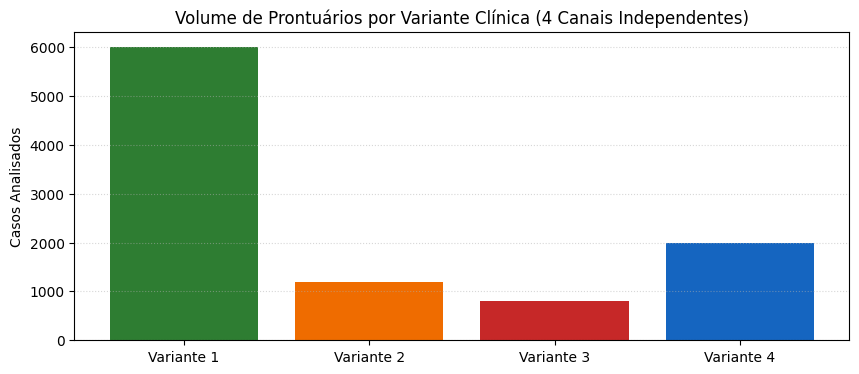


⏱️ Renderizando Mapa de Processos - Desempenho de Tempo (DFG)...


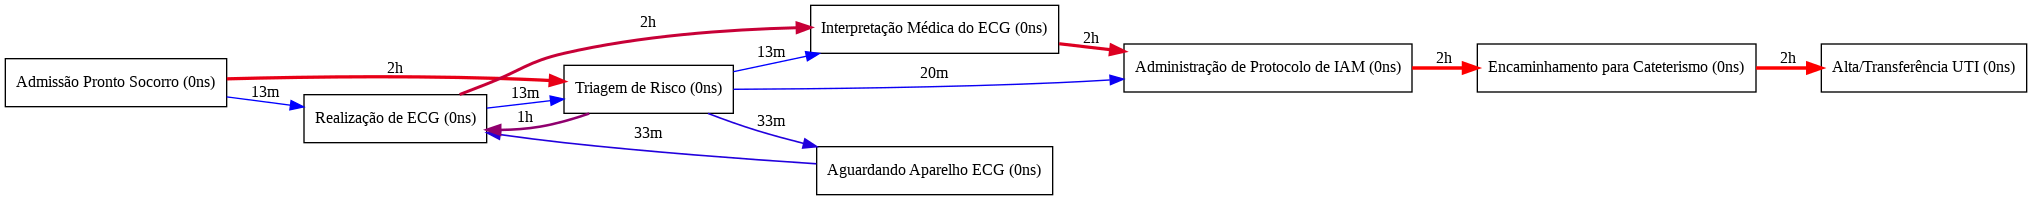


🔀 Renderizando Mapa de Processos - Volume de Tráfego (DFG)...


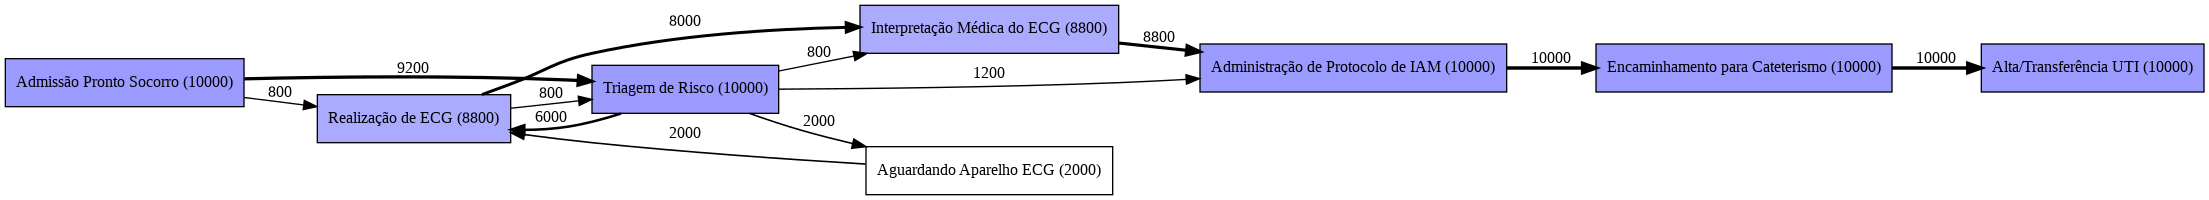


🏃 Renderizando Dispersão Estatística de Tempo de Atendimento...


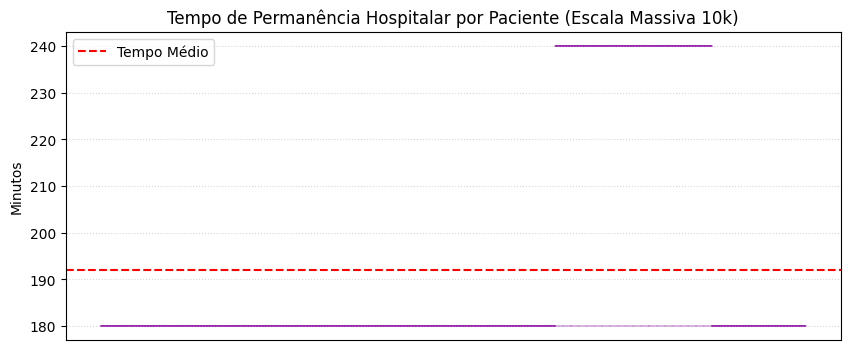


🕸️ Renderizando Rede de Petri Formal do Protocolo Clínico...


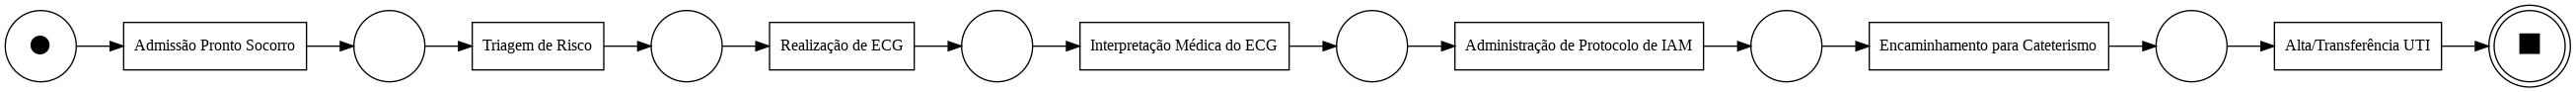

replaying log with TBR, completed traces ::   0%|          | 0/4 [00:00<?, ?it/s]


📊 INDEXADOR DE ADERÊNCIA CONCLUÍDO (FITNESS GERAL): 97.00%

💾 Arquivo CSV salvo com sucesso!


In [5]:
if __name__ == "__main__":
    TOTAL_CASOS = 10000
    df_historico, log_processado = gerar_event_log_iam(num_casos=TOTAL_CASOS)

    # Executa a nova função analítica antes dos plots
    auditoria_tempo_porta_ecg(df_historico)

    executar_auditoria_visual(df_historico, log_processado)
    df_historico.to_csv("event_log_iam_hospitalar.csv", index=False, encoding="utf-8")
    print("\n💾 Arquivo CSV salvo com sucesso!")